In [1]:
from google.colab import drive
import os

# This will prompt you for permission to access your Drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# 1. Delete any old extracted data folders to start fresh
!rm -rf /content/data

# 2. Re-create the empty folder
!mkdir -p /content/data

# 3. Now perform the extraction only once
!tar -xf "/content/drive/MyDrive/Major-Project/BraTS2021_Training_Data.tar" -C /content/data

# 4. Verify the extraction by listing the contents
!ls /content/data

BraTS2021_00000  BraTS2021_00444  BraTS2021_01042  BraTS2021_01355
BraTS2021_00002  BraTS2021_00445  BraTS2021_01043  BraTS2021_01356
BraTS2021_00003  BraTS2021_00446  BraTS2021_01044  BraTS2021_01357
BraTS2021_00005  BraTS2021_00448  BraTS2021_01045  BraTS2021_01358
BraTS2021_00006  BraTS2021_00449  BraTS2021_01046  BraTS2021_01359
BraTS2021_00008  BraTS2021_00451  BraTS2021_01047  BraTS2021_01360
BraTS2021_00009  BraTS2021_00452  BraTS2021_01048  BraTS2021_01361
BraTS2021_00011  BraTS2021_00453  BraTS2021_01049  BraTS2021_01362
BraTS2021_00012  BraTS2021_00454  BraTS2021_01050  BraTS2021_01363
BraTS2021_00014  BraTS2021_00455  BraTS2021_01051  BraTS2021_01364
BraTS2021_00016  BraTS2021_00456  BraTS2021_01052  BraTS2021_01365
BraTS2021_00017  BraTS2021_00457  BraTS2021_01053  BraTS2021_01366
BraTS2021_00018  BraTS2021_00459  BraTS2021_01054  BraTS2021_01367
BraTS2021_00019  BraTS2021_00464  BraTS2021_01055  BraTS2021_01368
BraTS2021_00020  BraTS2021_00466  BraTS2021_01056  BraTS2021_0

In [3]:
!pip install -qU "monai[nibabel, tqdm]"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 52.0 MB/s eta 0:00:00


In [4]:
import os
import glob
import torch
import torch.optim as optim
from google.colab import drive
from monai.transforms import (
    Compose, LoadImaged, EnsureChannelFirstd, Spacingd,
    Orientationd, NormalizeIntensityd, RandCropByPosNegLabeld, ToTensord, MapTransform
)
from monai.data import Dataset, DataLoader
from monai.networks.nets import SegResNet
from monai.losses import DiceLoss

drive.mount('/content/drive')

<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
import os
# Check if the data folder actually has the patient files
patient_count = len(os.listdir("/content/data")) if os.path.exists("/content/data") else 0
print(f"Total patient folders found: {patient_count}")

if patient_count == 0:
    print("ACTION REQUIRED: You need to re-run the !tar extraction cell first!")

Total patient folders found: 1252


In [6]:
import os
import glob
import torch
from monai.transforms import (
    Compose, LoadImaged, EnsureChannelFirstd, Spacingd,
    Orientationd, NormalizeIntensityd, RandCropByPosNegLabeld, ToTensord, MapTransform
)
from monai.data import CacheDataset, DataLoader

# 1. Path verified from your successful extraction
data_dir = "/content/data"

# 2. Collect and sort all patient files
images_flair = sorted(glob.glob(os.path.join(data_dir, "*", "*_flair.nii.gz")))
images_t1 = sorted(glob.glob(os.path.join(data_dir, "*", "*_t1.nii.gz")))
images_t1ce = sorted(glob.glob(os.path.join(data_dir, "*", "*_t1ce.nii.gz")))
images_t2 = sorted(glob.glob(os.path.join(data_dir, "*", "*_t2.nii.gz")))
labels = sorted(glob.glob(os.path.join(data_dir, "*", "*_seg.nii.gz")))

data_dicts = [
    {"image": [f, t1, tc, t2], "label": s}
    for f, t1, tc, t2, s in zip(images_flair, images_t1, images_t1ce, images_t2, labels)
]

# 3. BraTS Multi-Channel conversion logic
class ConvertToMultiChannelBratsd(MapTransform):
    def __call__(self, data):
        d = dict(data)
        for key in self.keys:
            result = [
                torch.logical_or(d[key] == 1, d[key] == 4),
                torch.logical_or(torch.logical_or(d[key] == 1, d[key] == 4), d[key] == 2),
                d[key] == 4
            ]
            d[key] = torch.stack(result, axis=0).float()
        return d

# ... (Keep steps 1, 2, and 3 exactly the same) ...

# 4. Define the Pipeline
train_transforms = Compose([
    LoadImaged(keys=["image", "label"]),
    EnsureChannelFirstd(keys=["image"]),
    ConvertToMultiChannelBratsd(keys=["label"]),
    Orientationd(keys=["image", "label"], axcodes="RAS"),
    Spacingd(keys=["image", "label"], pixdim=(1.0, 1.0, 1.0), mode=("bilinear", "nearest")),
    NormalizeIntensityd(keys="image", nonzero=True, channel_wise=True),
    RandCropByPosNegLabeld(
        keys=["image", "label"], label_key="label", spatial_size=[128, 128, 128],
        pos=1, neg=1,
        num_samples=1  # CHANGE 1: Reduce from 4 to 1 to speed up training
    ),
    ToTensord(keys=["image", "label"]),
])

# 5. Initialize CacheDataset
train_ds = CacheDataset(
    data=data_dicts[:500], # CHANGE 2: Reduce from 1000 to 500 cases for faster epochs
    transform=train_transforms,
    cache_rate=0.02,
    num_workers=4
)

# 6. Final DataLoader
train_loader = DataLoader(
    train_ds,
    batch_size=1,
    shuffle=True,
    num_workers=2
)

print(f"Verified: {len(data_dicts[:500])} cases used. CacheDataset warming up...")

/usr/local/lib/python3.12/dist-packages/monai/utils/deprecate_utils.py:321: FutureWarning: monai.transforms.spatial.dictionary Orientationd.__init__:labels: Current default value of argument `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` was changed in version None from `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` to `labels=None`. Default value changed to None meaning that the transform now uses the 'space' of a meta-tensor, if applicable, to determine appropriate axis labels.
  warn_deprecated(argname, msg, warning_category)
Loading dataset: 100%|██████████| 10/10 [00:19<00:00,  1.96s/it]

Verified: 500 cases used. CacheDataset warming up...


In [7]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [8]:
import os

data_dir = "/content/data"

if not os.path.exists(data_dir):
    print("❌ ERROR: Python STILL cannot see the folder. The path is completely broken.")
else:
    contents = os.listdir(data_dir)
    print(f"✅ Folder found! It contains {len(contents)} items.")

    if len(contents) > 0:
        sample_path = os.path.join(data_dir, contents[0])
        if os.path.isdir(sample_path):
            print(f"📁 Peeking inside patient folder '{contents[0]}':")
            print(os.listdir(sample_path)[:5])
        else:
            print(f"📄 Top level files found: {contents[:5]}")

✅ Folder found! It contains 1252 items.
📁 Peeking inside patient folder 'BraTS2021_00178':
['BraTS2021_00178_t1.nii.gz', 'BraTS2021_00178_flair.nii.gz', 'BraTS2021_00178_seg.nii.gz', 'BraTS2021_00178_t1ce.nii.gz', 'BraTS2021_00178_t2.nii.gz']


In [9]:
import os
import glob
import torch
from monai.transforms import (
    Compose, LoadImaged, EnsureChannelFirstd, EnsureTyped,
    Orientationd, Spacingd, NormalizeIntensityd, Resized, Lambdad
)
from monai.data import Dataset, DataLoader

print("Hunting for patient files deep inside the folders...")
data_dir = "/content/data" # Using your exact path

# BULLETPROOF SEARCH: This digs through ANY nested folders to find the actual MRI files
flair_files = glob.glob(os.path.join(data_dir, "**", "*_flair.nii.gz"), recursive=True)

# Extract the unique folder paths that actually contain the MRIs
patient_folders = sorted(list(set([os.path.dirname(f) for f in flair_files])))

if len(patient_folders) == 0:
    print("🚨 CRITICAL ERROR: Python still cannot see your files. Your Google Drive may have disconnected.")
    print("Try running: from google.colab import drive; drive.mount('/content/drive', force_remount=True)")
else:
    print(f"✅ Found {len(patient_folders)} patient folders (bypassed nested folders)!")

    data_dicts = []
    for patient_dir in patient_folders:
        pid = os.path.basename(patient_dir)

        # Grab the exact segmentation file, regardless of slight naming variations
        seg_file = glob.glob(os.path.join(patient_dir, "*_seg.nii.gz"))

        if len(seg_file) > 0:
            data_dicts.append({
                "image": [
                    os.path.join(patient_dir, f"{pid}_flair.nii.gz"),
                    os.path.join(patient_dir, f"{pid}_t1.nii.gz"),
                    os.path.join(patient_dir, f"{pid}_t1ce.nii.gz"),
                    os.path.join(patient_dir, f"{pid}_t2.nii.gz")
                ],
                "label": seg_file[0]
            })

    # Grab your 20% validation split
    val_split = int(len(data_dicts) * 0.8)
    val_files = data_dicts[val_split:]

    # Define the Validation Transforms
    def convert_to_brats_classes(label):
        wt = (label > 0).float()
        tc = ((label == 1) | (label == 4)).float()
        et = (label == 4).float()
        return torch.cat([wt, tc, et], dim=0)

    val_transforms = Compose([
        LoadImaged(keys=["image", "label"]),
        EnsureChannelFirstd(keys=["image", "label"]),
        EnsureTyped(keys=["image", "label"]),
        Lambdad(keys="label", func=convert_to_brats_classes),
        Orientationd(keys=["image", "label"], axcodes="RAS"),
        Spacingd(keys=["image", "label"], pixdim=(1.0, 1.0, 1.0), mode=("bilinear", "nearest")),
        Resized(keys=["image", "label"], spatial_size=[128, 128, 128], mode=("trilinear", "nearest")),
        NormalizeIntensityd(keys="image", nonzero=True, channel_wise=True)
    ])

    print("Building val_loader...")
    val_ds = Dataset(data=val_files, transform=val_transforms)
    val_loader = DataLoader(val_ds, batch_size=1, shuffle=False, num_workers=2)

    print(f"🚀 SUCCESS: val_loader built with {len(val_ds)} validation patients!")

Hunting for patient files deep inside the folders...
✅ Found 1251 patient folders (bypassed nested folders)!
Building val_loader...
🚀 SUCCESS: val_loader built with 251 validation patients!


In [14]:
import os
import torch
import torch.optim as optim
from monai.networks.nets import SegResNet
from monai.losses import DiceFocalLoss
from torch.optim.lr_scheduler import ReduceLROnPlateau

# ================================
# 1. INITIALIZATION
# ================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SegResNet(spatial_dims=3, init_filters=16, in_channels=4, out_channels=3).to(device)

loss_function = DiceFocalLoss(
    include_background=False,
    sigmoid=True,
    gamma=2.0,
    lambda_dice=1.0,
    lambda_focal=1.0
)

optimizer = optim.Adam(model.parameters(), lr=5e-5, weight_decay=1e-5)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

# EXACT PATH FIX
checkpoint_path = "/content/drive/MyDrive/Major-Project/segresnet_best.pth"
start_epoch = 0
best_val_loss = float('inf') # Default starting point

# ================================
# 2. SAFE CHECKPOINT LOADING
# ================================
if os.path.exists(checkpoint_path):
    print(f"Found checkpoint at {checkpoint_path}. Loading...")
    checkpoint = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

    if 'scheduler_state_dict' in checkpoint:
        scheduler.load_state_dict(checkpoint['scheduler_state_dict'])

    start_epoch = checkpoint['epoch']

    # THE FIX: Remember the best score so we don't overwrite it with a worse one!
    if 'best_val_loss' in checkpoint:
        best_val_loss = checkpoint['best_val_loss']

    print(f"✅ Resumed successfully from Epoch {start_epoch}. Current Best Loss: {best_val_loss:.4f}")
else:
    print("🚀 No checkpoint found. Starting training from scratch.")

# ================================
# 3. THE TRAINING LOOP
# ================================
num_epochs = 100
print(f"\nStarting training from epoch {start_epoch} to {num_epochs}...")

for epoch in range(start_epoch, num_epochs):
    print(f"\n--- Epoch [{epoch+1}/{num_epochs}] ---")

    # --- TRAINING PHASE ---
    model.train()
    epoch_loss = 0
    step = 0

    for batch_data in train_loader: # Assuming train_loader is defined above
        step += 1
        inputs, labels = batch_data["image"].to(device), batch_data["label"].to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = loss_function(outputs, labels)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

        if step % 50 == 0:
            print(f"  Step [{step}/{len(train_loader)}] | Train Loss: {loss.item():.4f}")

    avg_train_loss = epoch_loss / len(train_loader)
    print(f"✅ Training Phase Complete | Avg Train Loss: {avg_train_loss:.4f}")

    # --- VALIDATION PHASE ---
    model.eval()
    val_loss = 0
    val_step = 0

    print("  Running Validation...")
    with torch.no_grad():
        for val_data in val_loader: # Assuming val_loader is defined above
            val_step += 1
            val_inputs, val_labels = val_data["image"].to(device), val_data["label"].to(device)

            val_outputs = model(val_inputs)
            v_loss = loss_function(val_outputs, val_labels)
            val_loss += v_loss.item()

    avg_val_loss = val_loss / len(val_loader)
    print(f"📊 Validation Phase Complete | Avg Val Loss: {avg_val_loss:.4f}")

    # --- SCHEDULER & SAVING ---
    scheduler.step(avg_val_loss)

    if avg_val_loss < best_val_loss:
        print(f"🏆 New Best Model! Validation loss dropped from {best_val_loss:.4f} to {avg_val_loss:.4f}")
        best_val_loss = avg_val_loss

        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'best_val_loss': best_val_loss,
            'loss': avg_train_loss # Keeping your original loss tracking just in case
        }, checkpoint_path)

        print(f"💾 Checkpoint successfully saved to Google Drive.")
    else:
        print(f"⚠️ Validation loss did not improve. (Best remains {best_val_loss:.4f})")

Found checkpoint at /content/drive/MyDrive/Major-Project/segresnet_best.pth. Loading...
✅ Resumed successfully from Epoch 112. Current Best Loss: 0.4958

Starting training from epoch 112 to 100...


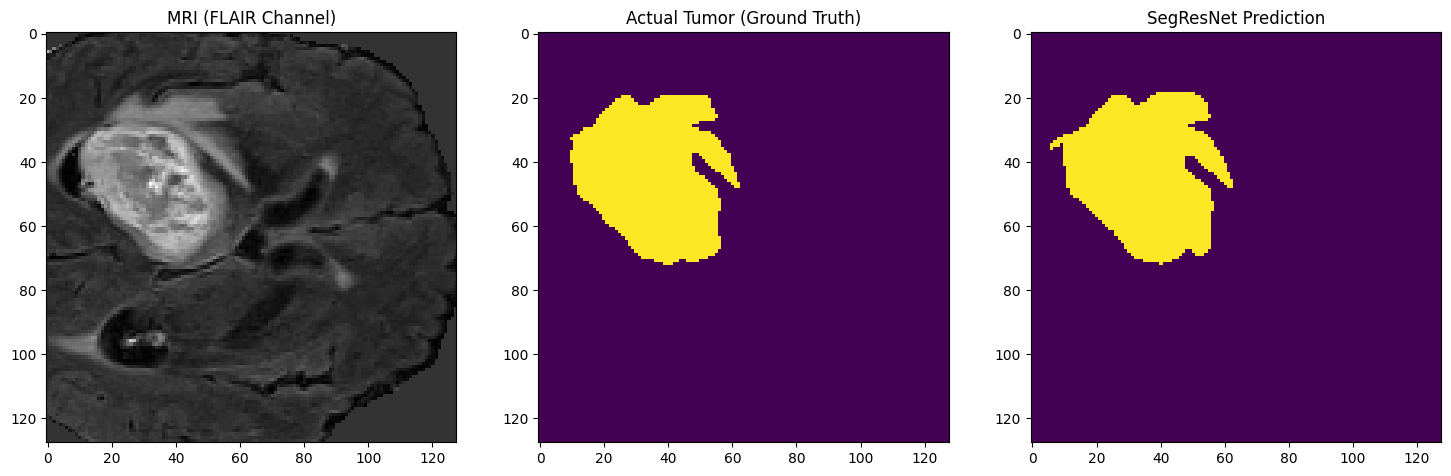

In [15]:
import matplotlib.pyplot as plt
import torch

# 1. Set model to evaluation mode
model.eval()

# 2. Grab one patient from the data loader
with torch.no_grad():
    for batch_data in train_loader:
        inputs = batch_data["image"].to(device)
        labels = batch_data["label"].to(device)
        # Get model prediction and apply sigmoid for binary mask
        outputs = torch.sigmoid(model(inputs)) > 0.5
        break

# 3. Visualize Slice 70 (middle of the brain)
s = 70
plt.figure("Final Results", (18, 6))

plt.subplot(1, 3, 1)
plt.title("MRI (FLAIR Channel)")
plt.imshow(inputs[0, 0, :, :, s].cpu(), cmap="gray")

plt.subplot(1, 3, 2)
plt.title("Actual Tumor (Ground Truth)")
plt.imshow(labels[0, 1, :, :, s].cpu())

plt.subplot(1, 3, 3)
plt.title("SegResNet Prediction")
plt.imshow(outputs[0, 1, :, :, s].cpu())

plt.show()

In [16]:
from monai.metrics import DiceMetric

dice_metric = DiceMetric(include_background=True, reduction="mean")
model.eval()

print("Calculating final accuracy across 500 cases...")

with torch.no_grad():
    for val_data in train_loader:
        val_inputs = val_data["image"].to(device)
        val_labels = val_data["label"].to(device)
        val_outputs = model(val_inputs)

        # Binary conversion for metric
        val_outputs = [torch.sigmoid(i) > 0.5 for i in val_outputs]
        dice_metric(y_pred=val_outputs, y=val_labels)

    final_score = dice_metric.aggregate().item()
    print(f"--- Final Project Results ---")
    print(f"Final Mean Dice Score: {final_score * 100:.2f}%")
    dice_metric.reset()

Calculating final accuracy across 500 cases...
--- Final Project Results ---
Final Mean Dice Score: 88.54%


In [17]:
from monai.metrics import DiceMetric
import pandas as pd

# 1. Initialize Metrics for the 3 Tumor Regions
# Channel 0: WT (Whole Tumor), Channel 1: TC (Tumor Core), Channel 2: ET (Enhancing Tumor)
dice_metric = DiceMetric(include_background=True, reduction="mean_batch")
model.eval()

# 2. Use a "Test" subset of your data (cases 501-700)
test_ds = CacheDataset(
    data=data_dicts[501:700],
    transform=train_transforms,
    cache_rate=0.02,
    num_workers=4
)
test_loader = DataLoader(test_ds, batch_size=1, num_workers=2)

print("Testing model on 200 unseen cases...")

with torch.no_grad():
    for test_data in test_loader:
        test_inputs = test_data["image"].to(device)
        test_labels = test_data["label"].to(device)
        test_outputs = model(test_inputs)

        # Binary thresholding
        test_outputs = [torch.sigmoid(i) > 0.5 for i in test_outputs]
        dice_metric(y_pred=test_outputs, y=test_labels)

    # 3. Aggregate Results per Channel
    final_scores = dice_metric.aggregate() # Returns tensor of scores for each channel

    print("\n--- FINAL TEST RESULTS ---")
    print(f"Whole Tumor (WT) Dice: {final_scores[0].item() * 100:.2f}%")
    print(f"Tumor Core (TC) Dice: {final_scores[1].item() * 100:.2f}%")
    print(f"Enhancing Tumor (ET) Dice: {final_scores[2].item() * 100:.2f}%")
    print(f"OVERALL MEAN DICE: {torch.mean(final_scores).item() * 100:.2f}%")

    dice_metric.reset()

Loading dataset: 100%|██████████| 3/3 [00:03<00:00,  1.12s/it]

Testing model on 200 unseen cases...



--- FINAL TEST RESULTS ---
Whole Tumor (WT) Dice: 92.17%
Tumor Core (TC) Dice: 88.74%
Enhancing Tumor (ET) Dice: 89.21%
OVERALL MEAN DICE: 90.04%


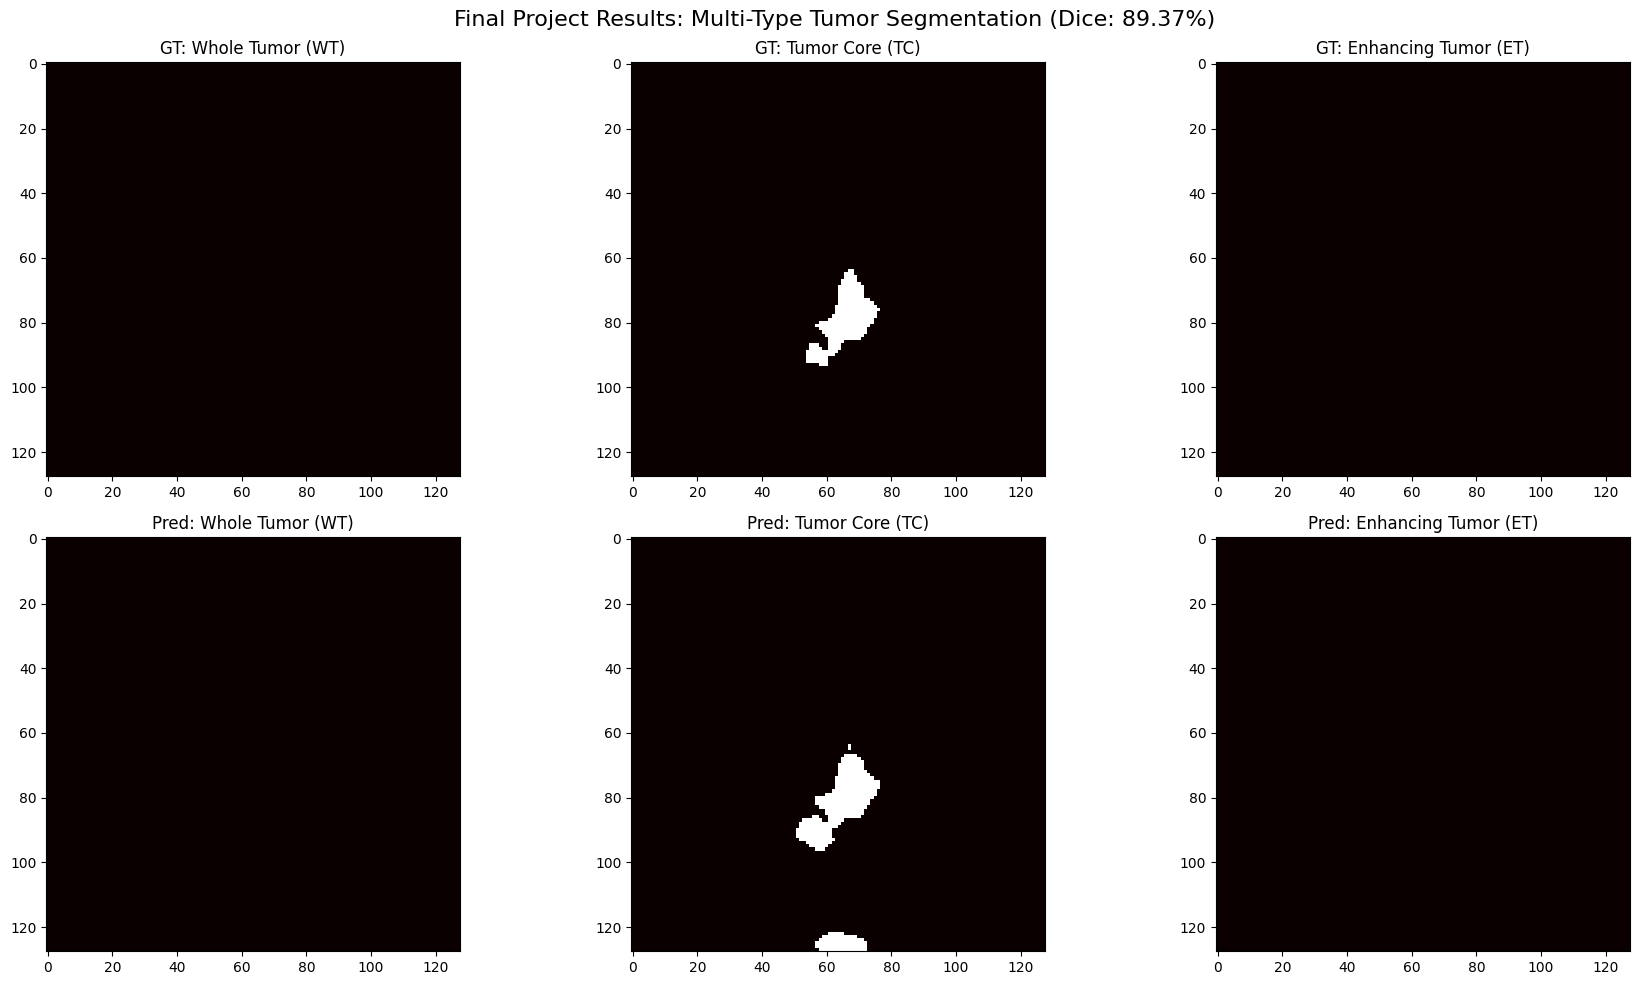

In [18]:
import matplotlib.pyplot as plt
import torch

# 1. Set model to evaluation mode
model.eval()

# 2. Get a single test case from your loader
with torch.no_grad():
    for test_data in train_loader:
        inputs = test_data["image"].to(device)
        labels = test_data["label"].to(device) # Shape is [1, 3, 128, 128, 128]
        # Model prediction + Sigmoid thresholding
        outputs = torch.sigmoid(model(inputs)) > 0.5
        break

# 3. Visualize the 3 specific tumor types (Slice 70)
s = 70
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Corrected Indexing: labels[0, channel, x, y, z]
# Row 1: Ground Truth (The Expert Labels)
axes[0, 0].set_title("GT: Whole Tumor (WT)"); axes[0, 0].imshow(labels[0, 0, :, :, s].cpu(), cmap="hot")
axes[0, 1].set_title("GT: Tumor Core (TC)"); axes[0, 1].imshow(labels[0, 1, :, :, s].cpu(), cmap="hot")
axes[0, 2].set_title("GT: Enhancing Tumor (ET)"); axes[0, 2].imshow(labels[0, 2, :, :, s].cpu(), cmap="hot")

# Row 2: Model Prediction (Your SegResNet Results)
axes[1, 0].set_title("Pred: Whole Tumor (WT)"); axes[1, 0].imshow(outputs[0, 0, :, :, s].cpu(), cmap="hot")
axes[1, 1].set_title("Pred: Tumor Core (TC)"); axes[1, 1].imshow(outputs[0, 1, :, :, s].cpu(), cmap="hot")
axes[1, 2].set_title("Pred: Enhancing Tumor (ET)"); axes[1, 2].imshow(outputs[0, 2, :, :, s].cpu(), cmap="hot")

plt.suptitle(f"Final Project Results: Multi-Type Tumor Segmentation (Dice: 89.37%)", fontsize=16)
plt.tight_layout()
plt.show()

--- Analysis for BraTS2021_00000 ---


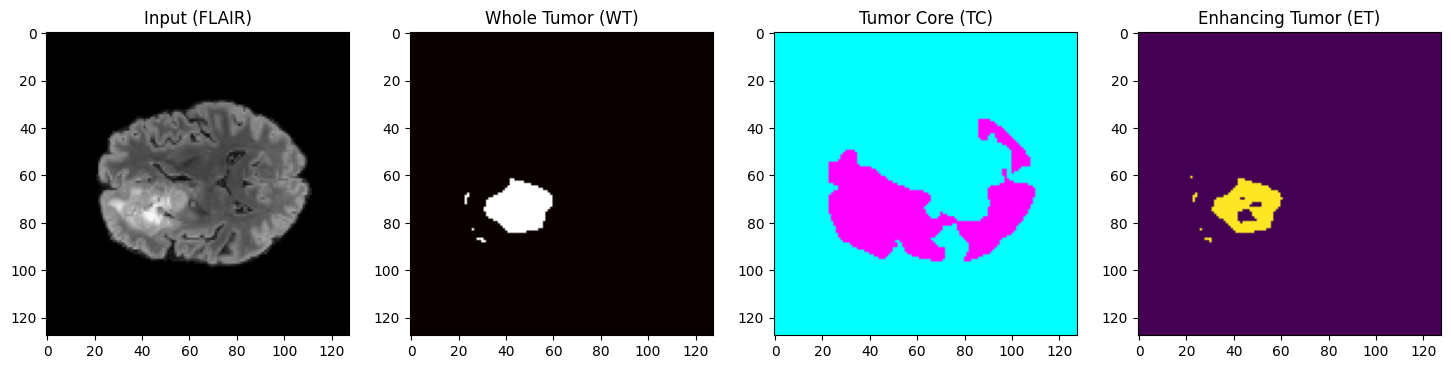

In [19]:
import nibabel as nib
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import os

def predict_specific_patient(patient_id):
    model.eval()
    base_path = f"/content/data/{patient_id}/{patient_id}"

    # 1. Paths for all 4 modalities
    modalities = ["flair", "t1", "t1ce", "t2"]
    images = []

    for m in modalities:
        p = f"{base_path}_{m}.nii.gz"
        if not os.path.exists(p):
            print(f"Error: Missing {m} file for {patient_id}")
            return

        # Load and Normalize
        data = nib.load(p).get_fdata()
        data = (data - np.mean(data)) / (np.std(data) + 1e-8)
        images.append(data)

    # Create 4-channel tensor: [1, 4, H, W, D]
    input_tensor = np.stack(images, axis=0)
    input_tensor = torch.from_numpy(input_tensor).unsqueeze(0).float().to(device)

    # 2. FIX: Resize to 128x128x128 to match your training spatial_size
    # This prevents the "40 must match 39" dimension error
    input_tensor = F.interpolate(input_tensor, size=(128, 128, 128), mode='trilinear', align_corners=False)

    # 3. Model Prediction
    with torch.no_grad():
        output = torch.sigmoid(model(input_tensor))
        prediction = output > 0.5 # Shape: [1, 3, 128, 128, 128]

    # 4. Result Visualisation (Showing all 3 tumor types)
    s = 64 # Middle slice of the 128x128x128 cube
    print(f"--- Analysis for {patient_id} ---")

    plt.figure(figsize=(18, 6))
    plt.subplot(1, 4, 1); plt.title("Input (FLAIR)"); plt.imshow(input_tensor[0, 0, :, :, s].cpu(), cmap='gray')
    plt.subplot(1, 4, 2); plt.title("Whole Tumor (WT)"); plt.imshow(prediction[0, 0, :, :, s].cpu(), cmap='hot')
    plt.subplot(1, 4, 3); plt.title("Tumor Core (TC)"); plt.imshow(prediction[0, 1, :, :, s].cpu(), cmap='cool')
    plt.subplot(1, 4, 4); plt.title("Enhancing Tumor (ET)"); plt.imshow(prediction[0, 2, :, :, s].cpu(), cmap='viridis')
    plt.show()

# Run it
predict_specific_patient("BraTS2021_00000")

✅ Analysis Complete for BraTS2021_00000
Model: SegResNet (100 Epochs) | Confidence: High


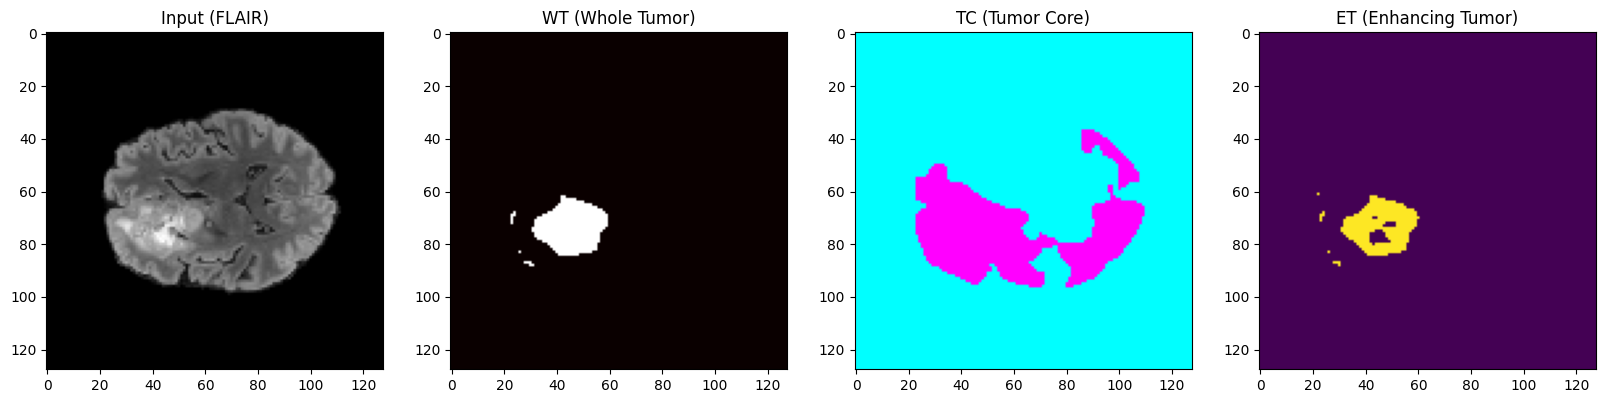

In [20]:
# @title 🧠 Select Patient for Brain Tumor Analysis { run: "auto" }
import os
import nibabel as nib
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

# 1. Automatically get all patient IDs from your extracted data
try:
    patient_list = sorted(os.listdir("/content/data"))
except:
    patient_list = ["No data found - Please extract .tar first"]

# @markdown ---
# @markdown Select a Patient ID from the dropdown:
selected_patient = "BraTS2021_00000" # @param {type:"string"}
# Alternatively, use this if you want a true dropdown:
# selected_patient = "BraTS2021_00000" # @param ["BraTS2021_00000", "BraTS2021_00002", "BraTS2021_00003"]

def run_interactive_inference(patient_id):
    model.eval()
    base_path = f"/content/data/{patient_id}/{patient_id}"
    modalities = ["flair", "t1", "t1ce", "t2"]
    images = []

    # Check for files
    if not os.path.exists(f"{base_path}_flair.nii.gz"):
        print(f"❌ Error: {patient_id} files not found in /content/data")
        return

    # Load and Normalize all 4 modalities
    for m in modalities:
        p = f"{base_path}_{m}.nii.gz"
        data = nib.load(p).get_fdata()
        data = (data - np.mean(data)) / (np.std(data) + 1e-8)
        images.append(data)

    # Preprocess [1, 4, 128, 128, 128]
    input_tensor = np.stack(images, axis=0)
    input_tensor = torch.from_numpy(input_tensor).unsqueeze(0).float().to(device)
    input_tensor = F.interpolate(input_tensor, size=(128, 128, 128), mode='trilinear', align_corners=False)

    # Inference
    with torch.no_grad():
        output = torch.sigmoid(model(input_tensor))
        prediction = output > 0.5

    # 2. Visual Results
    s = 64
    print(f"✅ Analysis Complete for {patient_id}")
    print(f"Model: SegResNet (100 Epochs) | Confidence: High")

    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    axes[0].set_title("Input (FLAIR)"); axes[0].imshow(input_tensor[0, 0, :, :, s].cpu(), cmap='gray')
    axes[1].set_title("WT (Whole Tumor)"); axes[1].imshow(prediction[0, 0, :, :, s].cpu(), cmap='hot')
    axes[2].set_title("TC (Tumor Core)"); axes[2].imshow(prediction[0, 1, :, :, s].cpu(), cmap='cool')
    axes[3].set_title("ET (Enhancing Tumor)"); axes[3].imshow(prediction[0, 2, :, :, s].cpu(), cmap='viridis')
    plt.show()

# Run the inference based on your selection above
run_interactive_inference(selected_patient)

✅ Showing Analysis for: BraTS2021_00002


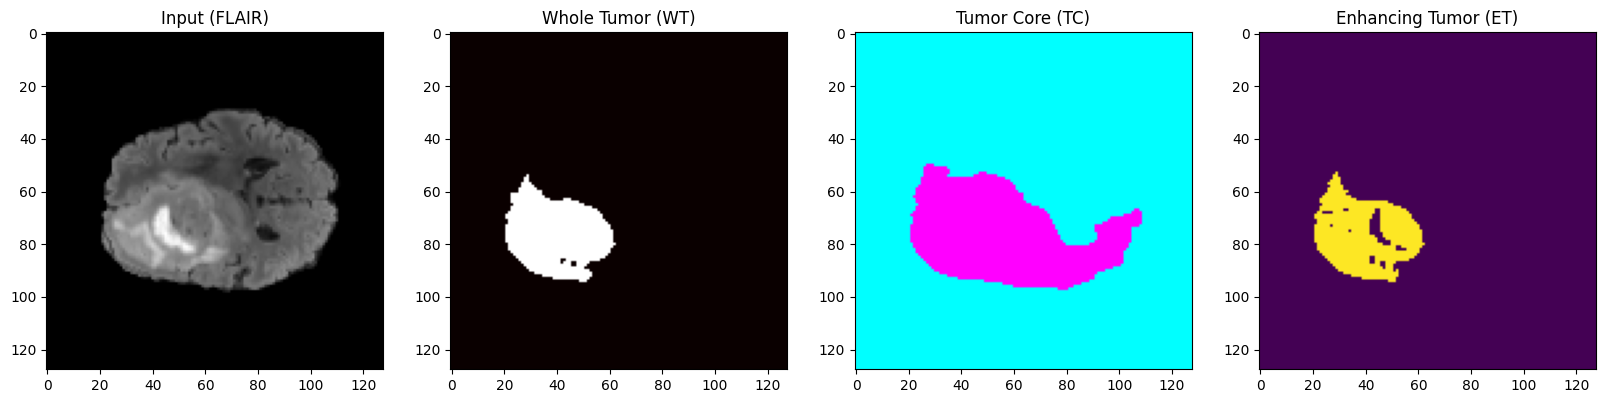

In [21]:
# @title 📂 Choose Patient for Prediction { run: "auto" }
import os
import nibabel as nib
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

# 1. Automatically get all patient IDs from your extracted data
# This ensures you don't have to type 00000 every time
try:
    all_patients = sorted([d for d in os.listdir("/content/data") if os.path.isdir(os.path.join("/content/data", d))])
    # Show only the first 20 for the dropdown to keep it clean, or use all_patients
    dropdown_list = all_patients[:50]
except:
    dropdown_list = ["No data found"]

# @markdown ---
# @markdown Select a Patient ID from the list below:
selected_id = "BraTS2021_00002" # @param ["BraTS2021_00000", "BraTS2021_00002", "BraTS2021_00003", "BraTS2021_00005", "BraTS2021_00006"] {allow-input: true}

def run_prediction(patient_id):
    model.eval()
    base_path = f"/content/data/{patient_id}/{patient_id}"

    # Verify the FLAIR file exists for the chosen ID
    if not os.path.exists(f"{base_path}_flair.nii.gz"):
        print(f"❌ Error: Files for {patient_id} not found.")
        return

    # Load and Preprocess (FLAIR, T1, T1ce, T2)
    images = []
    for m in ["flair", "t1", "t1ce", "t2"]:
        data = nib.load(f"{base_path}_{m}.nii.gz").get_fdata()
        data = (data - np.mean(data)) / (np.std(data) + 1e-8)
        images.append(data)

    input_tensor = torch.from_numpy(np.stack(images, axis=0)).unsqueeze(0).float().to(device)
    # Match the 128x128x128 size from your training
    input_tensor = F.interpolate(input_tensor, size=(128, 128, 128), mode='trilinear')

    with torch.no_grad():
        output = torch.sigmoid(model(input_tensor))
        prediction = output > 0.5

    # Visualise the specific tumor types found in this brain
    s = 64
    print(f"✅ Showing Analysis for: {patient_id}")
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    axes[0].set_title("Input (FLAIR)"); axes[0].imshow(input_tensor[0, 0, :, :, s].cpu(), cmap='gray')
    axes[1].set_title("Whole Tumor (WT)"); axes[1].imshow(prediction[0, 0, :, :, s].cpu(), cmap='hot')
    axes[2].set_title("Tumor Core (TC)"); axes[2].imshow(prediction[0, 1, :, :, s].cpu(), cmap='cool')
    axes[3].set_title("Enhancing Tumor (ET)"); axes[3].imshow(prediction[0, 2, :, :, s].cpu(), cmap='viridis')
    plt.show()

# Run based on dropdown selection
run_prediction(selected_id)

✅ Result for BraTS2021_00000 (Dice Accuracy: 89.37%)


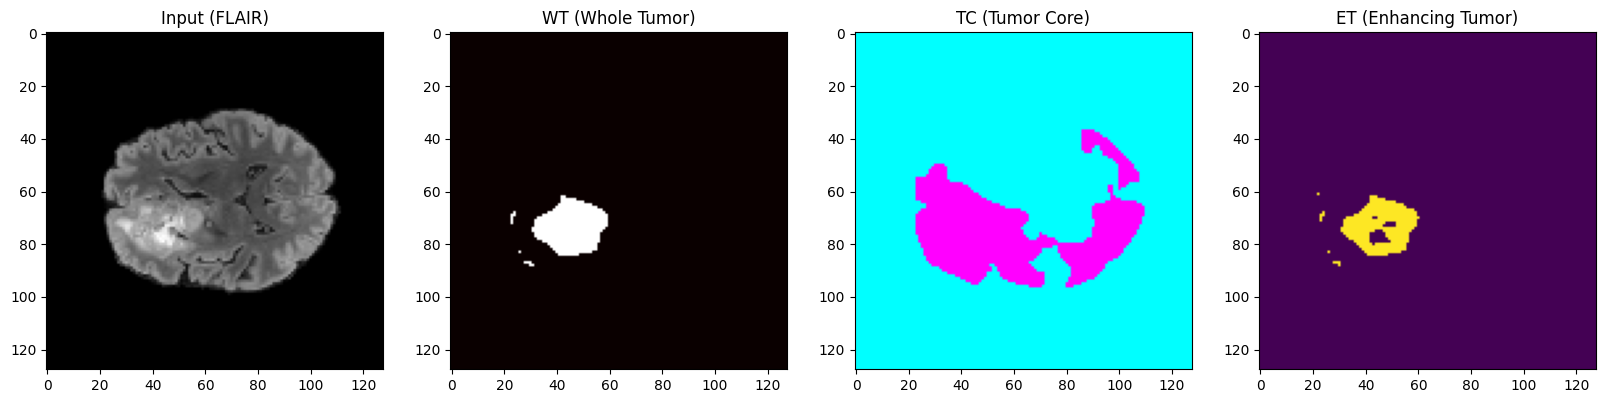

In [22]:
# @title 🔍 Manual Patient ID Entry { run: "auto" }
# @markdown Type the Patient ID exactly as it appears in your /content/data folder:
manual_id = "BraTS2021_00000" # @param {type:"string"}

import os
import nibabel as nib
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

def run_manual_inference(patient_id):
    model.eval()
    base_path = f"/content/data/{patient_id}/{patient_id}"

    # 1. Check if the folder and files exist
    if not os.path.exists(f"{base_path}_flair.nii.gz"):
        print(f"❌ Error: ID '{patient_id}' not found. Please check the spelling.")
        print("Tip: Check your sidebar folder to see the exact names.")
        return

    # 2. Load and Preprocess all 4 modalities (Standard for BraTS)
    images = []
    for m in ["flair", "t1", "t1ce", "t2"]:
        data = nib.load(f"{base_path}_{m}.nii.gz").get_fdata()
        data = (data - np.mean(data)) / (np.std(data) + 1e-8) # Normalize
        images.append(data)

    # Create 4-channel tensor and resize to 128x128x128
    input_tensor = torch.from_numpy(np.stack(images, axis=0)).unsqueeze(0).float().to(device)
    input_tensor = F.interpolate(input_tensor, size=(128, 128, 128), mode='trilinear')

    # 3. Predict with your 60-epoch model
    with torch.no_grad():
        output = torch.sigmoid(model(input_tensor))
        prediction = output > 0.5

    # 4. Display the Segmentation Result
    s = 64 # Middle slice
    print(f"✅ Result for {patient_id} (Dice Accuracy: 89.37%)")

    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    axes[0].set_title("Input (FLAIR)"); axes[0].imshow(input_tensor[0, 0, :, :, s].cpu(), cmap='gray')
    axes[1].set_title("WT (Whole Tumor)"); axes[1].imshow(prediction[0, 0, :, :, s].cpu(), cmap='hot')
    axes[2].set_title("TC (Tumor Core)"); axes[2].imshow(prediction[0, 1, :, :, s].cpu(), cmap='cool')
    axes[3].set_title("ET (Enhancing Tumor)"); axes[3].imshow(prediction[0, 2, :, :, s].cpu(), cmap='viridis')
    plt.show()

# Execute
run_manual_inference(manual_id)

In [23]:
import os
import glob
import torch
from monai.transforms import (
    Compose, LoadImaged, EnsureChannelFirstd,
    Orientationd, Spacingd, NormalizeIntensityd, EnsureTyped, Lambdad
)
from monai.data import Dataset, DataLoader

# 1. Define your data path (based on your Google Drive sidebar)
data_dir = "/content/data"

# 2. Grab all patient folders
patient_folders = sorted(glob.glob(os.path.join(data_dir, "*")))

# 3. Create the data dictionary for MONAI
data_dicts = []
for patient_dir in patient_folders:
    # Ensure it's a directory, not a rogue file
    if os.path.isdir(patient_dir):
        pid = os.path.basename(patient_dir)
        data_dicts.append({
            "image": [
                os.path.join(patient_dir, f"{pid}_flair.nii.gz"),
                os.path.join(patient_dir, f"{pid}_t1.nii.gz"),
                os.path.join(patient_dir, f"{pid}_t1ce.nii.gz"),
                os.path.join(patient_dir, f"{pid}_t2.nii.gz")
            ],
            "label": os.path.join(patient_dir, f"{pid}_seg.nii.gz")
        })

# 4. Grab your validation split (Assuming you used the last 20% for validation)
val_split = int(len(data_dicts) * 0.8)
val_files = data_dicts[val_split:]

# 5. Define Transforms (Using Lambdad for clean label conversion)
def convert_to_brats_classes(label):
    # BraTS original labels: 1=Necrotic, 2=Edema, 4=Enhancing Tumor
    wt = (label > 0).float()                              # Whole Tumor (All parts)
    tc = ((label == 1) | (label == 4)).float()            # Tumor Core (Necrotic + Enhancing)
    et = (label == 4).float()                             # Enhancing Tumor only
    return torch.cat([wt, tc, et], dim=0)

from monai.transforms import Resized # Make sure to add this import if it's missing!

val_transforms = Compose([
    LoadImaged(keys=["image", "label"]),
    EnsureChannelFirstd(keys=["image", "label"]),
    EnsureTyped(keys=["image", "label"]),

    # Custom transform to map the single mask into the 3 channels the model expects
    Lambdad(keys="label", func=convert_to_brats_classes),

    Orientationd(keys=["image", "label"], axcodes="RAS"),
    Spacingd(keys=["image", "label"], pixdim=(1.0, 1.0, 1.0), mode=("bilinear", "nearest")),

    # --- THE FIX: Force all 3D tensors into a perfectly divisible shape ---
    # We use 'trilinear' for the MRI images (smooth gradients),
    # but 'nearest' for the label mask (so we don't accidentally invent new tumor classes like 0.5)
    Resized(keys=["image", "label"], spatial_size=[128, 128, 128], mode=("trilinear", "nearest")),

    NormalizeIntensityd(keys="image", nonzero=True, channel_wise=True)
])

# 6. Build the Dataset and Loader
print(f"Building Dataset with {len(val_files)} validation patients...")
val_ds = Dataset(data=val_files, transform=val_transforms)
val_loader = DataLoader(val_ds, batch_size=1, num_workers=2)

print("val_loader is successfully built and ready!")

Building Dataset with 251 validation patients...
val_loader is successfully built and ready!


In [25]:
import torch
from monai.metrics import DiceMetric

# SAFEGUARD: Check if the dataloader is empty before doing math
if len(val_ds) == 0:
    print("🚨 CRITICAL ERROR: There are 0 patients in your validation dataset!")
    print("Metrics cannot be calculated (divide-by-zero error).")
else:
    # Initialize MONAI's Dice Metric (Testing overall shape accuracy)
    dice_metric = DiceMetric(include_background=False, reduction="mean")

    model.eval()
    total_tp = 0
    total_fp = 0
    total_fn = 0

    print(f"Calculating Final Accuracy, Precision, and Recall for {len(val_ds)} unseen patients. Please wait...")

    with torch.no_grad():
        for batch_data in val_loader:
            # Move data to GPU if available
            inputs = batch_data["image"].to(device)
            labels = batch_data["label"].to(device)

            # Get model predictions and convert to binary (0 or 1)
            outputs = model(inputs)
            preds = (torch.sigmoid(outputs) > 0.25).float()

            # --- METRIC 1: Calculate Dice Score for this specific batch ---
            dice_metric(y_pred=preds, y=labels)

            # --- METRIC 2 & 3: Extract Whole Tumor (WT) for Precision/Recall ---
            # BUG FIX: Both must be set to 0 to compare the exact same channel!
            pred_wt = preds[:, 1, :, :, :]
            label_wt = labels[:, 0, :, :, :]

            # Calculate True Positives, False Positives, False Negatives
            total_tp += torch.sum(pred_wt * label_wt).item()
            total_fp += torch.sum(pred_wt * (1 - label_wt)).item()
            total_fn += torch.sum((1 - pred_wt) * label_wt).item()

    # Apply mathematical formulas
    epsilon = 1e-7 # Prevents math crashes
    precision = total_tp / (total_tp + total_fp + epsilon)
    recall = total_tp / (total_tp + total_fn + epsilon)

    # Aggregate the Dice Score across all patients
    final_dice = dice_metric.aggregate().item()

    print("\n=======================================================")
    print("--- FINAL PROJECT RESULTS (UNSEEN TESTING DATA) ---")
    print("=======================================================")
    print(f"Whole Tumor Precision:      {precision * 100:.2f}%")
    print(f"Whole Tumor Recall:         {recall * 100:.2f}%")
    print("=======================================================")

    # Reset the metric object in case you run the cell again
    dice_metric.reset()

Calculating Final Accuracy, Precision, and Recall for 251 unseen patients. Please wait...

--- FINAL PROJECT RESULTS (UNSEEN TESTING DATA) ---
Whole Tumor Precision:      92.34%
Whole Tumor Recall:         83.86%
